## Setup
Default kaggle setup and additional imports.

In [47]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


## EDA
To understand the data I am working with I will first explore the datasets structure and characteristics. Then I will look for any missing values in the data and the distribution of the target variable which is SalePrice within the training data. This will give me a better understanding of what to focus on when cleaning the data and how I could appropriately model the data.

In [48]:
#Obtaining general structure and charactaristics of the data

train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print(train.shape)
print(test.shape)
print(train.describe())
train.head()

(1460, 81)
(1459, 80)
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.0

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [49]:
#Looking at missing values in the data

missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(f"Train:\n{missing_train}")

missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(f"\nTest:\n{missing_test}")

Train:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Test:
PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageQual        78
GarageCond        78
GarageYrBlt       78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
Functional         2
BsmtFullBath       2
Utilities          2
BsmtHalfBath       2
Exterior1st        1
Exterior2nd        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFin

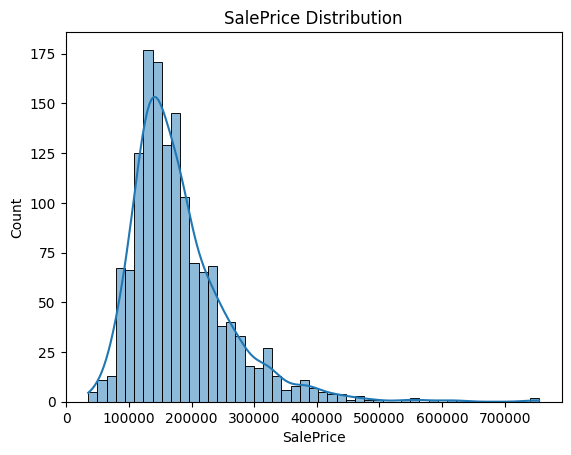

Skewness: 1.8828757597682129


In [50]:
#Visualising the distribution of SalePrice in the training data

sns.histplot(train['SalePrice'], kde=True)
plt.title('SalePrice Distribution')
plt.show()

print(f"Skewness: {train['SalePrice'].skew()}")

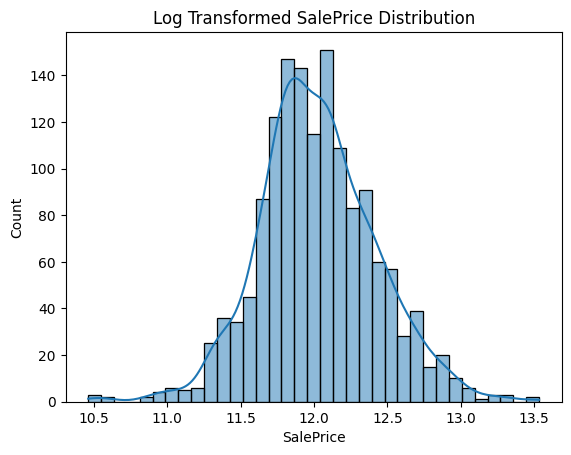

Skewness: 0.12134661989685333


In [51]:
#Visualisng log transformed SalePrice to correct skew

SalePrice_log = np.log1p(train['SalePrice'])

sns.histplot(SalePrice_log, kde=True)
plt.title('Log Transformed SalePrice Distribution')
plt.show()

print(f"Skewness: {SalePrice_log.skew()}")

## EDA Findings

By performing exploratory data analysis there are a few conclusions that can be made about the data. Firstly a lot of the missing values are meaningful and represent where a property just doesn't have a specific feature such as a pool, basement or garage. There are however some instances where the data will need to be cleaned such as the large amount of missing values for `LotFrontage`. Several additional columns contain missing data within the test set and these gaps are not in the training set. From this it can be deduced that cleaning will also need to handle these instances to ensure there are no issues when modelling.

Looking at the distribution of the target variable `SalePrice` is also helpful as it shows that there is a significant positive skew (1.88) which needs to be corrected before modeling. Visualising the log transformation on `SalePrice` makes it clear that this resolves the skew issue by reducing it to 0.12.

## Data Cleaning

Before starting to model it is crucial that I apply my findings from the EDA by cleaning the data. This will ensure that there are no errors when modelling and that accurate predictions can be made. It is important to note that any missing values that will be filled with an estimation should only be filled using training data and not test data.

In [52]:
#Log transform of SalePrice
#Step needs to be reversed on model output for test data
train['SalePrice'] = np.log1p(train['SalePrice'])

#Lists of features where missing values is meaningful data
none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']

zero_cols = ['GarageYrBlt','GarageArea','GarageCars','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath','MasVnrArea']

#Replacing missing values in these columns with values the model can use
for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

for col in zero_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

#List of features where missing values should be filled using the mode
mode_cols = ['Electrical','MSZoning','Functional','Utilities','Exterior1st','Exterior2nd','KitchenQual','SaleType']

#Replacing missing values in these columns with the mode
for col in mode_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(train[col].mode()[0])

#Cleaning LotFrontage by using median value within the neighbourhood
lot_frontage_medians = train.groupby('Neighborhood')['LotFrontage'].median()

train['LotFrontage'] = train['LotFrontage'].fillna(train['Neighborhood'].map(lot_frontage_medians))
test['LotFrontage'] = test['LotFrontage'].fillna(test['Neighborhood'].map(lot_frontage_medians))

In [53]:
#Reviewing missing values in the data to ensure cleaning has corrected everything

print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
0


## Data Cleaning Summary

The first part of data cleaning involved doing a log transform on `SalePrice` for the training data. This removes the skew that had been uncovered in the EDA phase but it is important to note that this step will need to be reversed to provide correct predictions when the model is dealing with test data.

Next any meaningful absences in data were replaced with values that are useful to the model such as None or 0. Instead of having no data the model can look at these as their own category or value and use it to inform predictions. Other missing gaps were then filled with the mode value of that feature as an estimation of what they should be with the exception of `LotFrontage`.

To handle missing values for `LotFrontage` the assumption was made that lots in the same neighbourhood tend to be similarly sized. With this assumption the median of lots in the neighbourhood can be used to estimate `LotFrontage` where there is no data. This approach means that `LotFrontage` can be filled out more accurately than just taking the overall mean lot frontage of every lot.

As previously stated, it is important that when data cleaning takes place only the training data is used to derive values that will fill gaps in the test data. In a real world scenario only the training data would be available and the test data would be what the model encounters when it is actually being used to make predictions. Any data from the test set needs to remain as unseen to the model to ensure its performance metrics genuinely reflect its ability. If it has indirectly seen data from the test set this would be called a data leak and would inflate the performance of the model.

## Feature Engineering

Feature engineering is a key method I will use to better capture underlying patterns in the data. I will need to augment existing features to better represent how they contribute to `SalePrice` and create new features by combining existing ones. 

In [54]:
#Creating a feature to represent the total square footage of the house
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

#Creating a feature to represent the total number of bathrooms counting a half bath as 0.5
train['TotalBathrooms'] = (train['FullBath'] + (0.5 * train['HalfBath']) + train['BsmtFullBath'] + (0.5 * train['BsmtHalfBath']))
test['TotalBathrooms'] = (test['FullBath'] + (0.5 * test['HalfBath']) + test['BsmtFullBath'] + (0.5 * test['BsmtHalfBath']))

#Creating a feature to represent the age of the house at the point of sale
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

#Creating a feature to represent how long since the house was remodeled at the point of sale
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
test['RemodAge'] = test['YrSold'] - test['YearRemodAdd']

#Encoding any categorical features
le = LabelEncoder()
for col in categorical_cols:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

#Creating binary flags for certain features
for df in [train, test]:
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

## Feature Engineering Summary

Many of the features within the dataset contained useful information but hold less meaning when they are looked at in isolation. The first step was to combine some of these features in to new ones which are more representative. Using the multiple square foot features a total square foot value can be obtained and held as a new feature `TotalSF`. The same can be done for bathrooms whilst taking into account that a half bath holds less value than a full bath to create the `TotalBathrooms` feature. The age of the house and how long ago it was last remodelled at the time of the sale can also be obtained from the existing features and have both been added as `HouseAge` and `RemodAge` respectively.

Next the categorical features needed to be encoded to make sure that the model can interpret them during training. A label encoder was used for this. Something to note is that the method used in this step could have caused an issue if there were categories present in the test data that did not appear in the training data however this was not the case. This is because the transform has to be fit to the training data and then applied to the test data as well. Fitting the transform to the test data can also cause a data leak which is mentioned in the data cleaning section.

Finally a couple of binary flags were created for certain features. An example of this is the `HasPool` flag where it can be assumed that if a house has a pool vs does not have a pool there is more likely to be a difference in `SalePrice` than two houses that both have pools of differing sizes.

## Modelling

I will be training and evaluating the models using cross validation so that I can get an estimate of the performance which is more reliable than a single train/test split. To begin I will start by looking at a Random Forest model to get a baseline RMSE score as I have some prior experience modelling with those. I will then move on to using XGBoost which should perform better than the random forest and from there I will look at tuning the hyperparameters for the XGBoost model.

In [55]:
#Setting up test and train data for models

X_train = train.drop(['SalePrice', 'Id'], axis=1)
y_train = train['SalePrice']
X_test = test.drop(['Id'], axis=1)

In [56]:
#Random Forest model

rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)
print(f"Random Forest RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

Random Forest RMSE: 0.1419 (+/- 0.0077)


In [57]:
#XGBoost model

xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-scores)
print(f"XGBoost RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

XGBoost RMSE: 0.1350 (+/- 0.0094)


In [58]:
#Hyperparameter tuning

#Picked reasonable increments around the hyperparameter choices of the base model
param_grid = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

xgb_tuned = XGBRegressor(random_state=42)
grid_search = GridSearchCV(xgb_tuned, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500}
Best RMSE: 0.1253


### Final Model

In [59]:
#Final model for submission

#Training the final model with the best hyperparameters found
final_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42)
final_model.fit(X_train, y_train)

#Making predictions for the test data remembering to reverse the log transform
predictions= np.expm1(final_model.predict(X_test))

#Submission file
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

     Id      SalePrice
0  1461  127728.789062
1  1462  162651.531250
2  1463  181752.375000
3  1464  191777.968750
4  1465  189063.812500


## Results

To get an idea of a baseline score for the RMSE a Random Forest model was used to begin with. This is a simpler model and served as the benchmark to compare XGBoost with. The Random Forest Model ended up with a RMSE of 0.1419 which is a reasonably good starting point. The standard deviation came out as 0.0077 across the 5 cross validation folds which showed that the model performed fairly consistently and was not getting lucky/unlucky depending on the data presented to it.

After this an XGBoost model was created with some default hyperparameters. This resulted in a RMSE of 0.1350 which was a modest improvement and expected from XGBoost due to the method it uses. XGBoost uses gradient boosting which builds decision trees sequentially and allows each new tree to target and correct the errors made by the previous tree. In contrast to this, Random Forest models build decision trees independently and then averages their predictions. The trees act separately and cannot learn from eachother whereas XGBoost's corrections allow it to progressively improve at handling cases it struggles with. The added complexity of XGBoost means it is more sensitive to the fold splits and therefore the standard deviation has increased to 0.0094 but this value is still reasonably stable.

Improving the XGBoost model further, hyperparameter tuning was employed to increase model accuracy. Picking values either side of the untuned model for `n_estimators` and `learning_rate` gives a gauge as to which direction to adjust. For `max_depth` the untuned model just used the preset value which is 6 and since deeper trees are prone to overfitting the values picked were all shallower. These values were then tested using a Grid Search which provided the best set of hyperparameters out of all the options. This turned out to be `n_estimators=500` `learning_rate=0.05` and `max_depth=3`. Within this result there is a clear pattern that simpler parameters performed the best, meaning that a shallower depth and fewer trees was ideal and that the untuned XGBoost model could have actually been overfitting to the data. The RMSE score using the best set of parameters turned out as 0.1253 which is a significant improvement to the untuned XGBoost and much better than the benchmark score that the Random Forest achieved.

Creating a final model out of these hyperparameters and generating predictions on the test set of data resulted in a leaderboard score of 0.12958. This placed me 2162/5074 at the time of submission putting me in the top 43%. This result was achieved without any advanced techniques which is good for a first submission. The leaderboard score is very close to the cross validation score which suggests that the model is doing a good job of generalising.

## Conclusion

The aim of this project was to predict house sale prices using the Kaggle House Prices dataset. By approaching the task systematically and following a structure of EDA -> Data Cleaning -> Feature Engineering -> Modelling I was able to create an XGBoost model which achieved a leaderboard RMSE of 0.12958 which places me in the top 43% of submissions.

When reflecting on the project there are multiple choices which I have made that have worked well. During data cleaning I made several thoughtful choices such as using a neighbourhood median approach for the `LotFrontage` feature and picking up on certain missing values that still encoded data about a house. Engineering new features such as `TotalSF` and `HouseAge` were logical additions which positively impacted the result. Looking at my modelling section it is clear that tuning hyperparameters had a substantial impact in reducing the RMSE and the cross validation score being so close to the leaderboard score shows that the model is generalising well.

My approach to the project also comes with some limitations. In terms of feature engineering the label encoding method does not preserve the ordinal relationships in columns that represent a quality rating and I could have explored many more combinations to create more new features. When tuning hyperparameters the grid search only tested a coarse set of values so there may be better options that I have not yet discovered.

To improve my RMSE score I can look at both rectifying some of the aforementioned limitations and also adding in new approaches. Firstly for the limitations, more sophisticated ordinal encoding could be used for features of that nature and introducing some interaction terms could help to capture non-linear relationships more explicitly. Also using `RandomizedSearchCV` instead of `GridSearchCV` would help to search wider for better hyperparameters. After that, I could try some new approaches such as an Ensemble approach where models are combined to produce an overall result such as combining XGBoost and a linear model like Lasso. I could also look at correcting skew for numeric features other than just `SalePrice`.